# Exploratory Data Analysis (EDA)

This notebook explores NinaPro DB1 sEMG signals at two levels:
1) Subject 01 deep dive, and
2) Overall variability across subjects and movements.


## What you will do
- Load the prebuilt DB dictionary from disk.
- Remap movement IDs to a global, contiguous range (consistent with modeling).
- Analyze Subject 01 sEMG (label balance, rest vs. movement, channels, repetitions).
- Analyze overall variability across subjects and movements.
- Inspect global gesture frequency and class imbalance.


In [1]:
import sys
from pathlib import Path

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.datasets import _build_movement_id_maps, _remap_restimulus

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

## Load prebuilt DB dictionary
This uses the pickle created in Notebook 01 so we can focus on analysis.


In [2]:

DB_PATH = Path("../data/processed/db1_a1.pkl")
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Missing DB pickle: {DB_PATH}. Run notebook 01 to build it."
    )

with DB_PATH.open("rb") as f:
    db = pickle.load(f)

## Subject 01 analysis

In [3]:
SUBJECT_ID = 1
EXERCISE_ID = 1
record = db[SUBJECT_ID]["exercises"][EXERCISE_ID]
emg = record["emg"]

movement_maps = _build_movement_id_maps(db[SUBJECT_ID]["exercises"])
restimulus_raw = record["restimulus"]
restimulus = _remap_restimulus(restimulus_raw, movement_maps[EXERCISE_ID])

rerepetition = record["rerepetition"]

### Label distribution (Subject 01)
Rest (label 0) dominates a large portion of the recording.
This matters for accuracy metrics and for choosing evaluation protocols.

In NinaPro DB1, the rest class (label 0) accounts for more than 50% of all samples, while each active movement contributes only < 5%. As shown by Atzori et al., this leads to a strong bias toward correctly classifying rest and can inflate overall accuracy by a large margin. High accuracy therefore does not necessarily imply good movement recognition performance. For this reason, results should always be interpreted alongside per-class metrics and with explicit awareness of the dominance of the rest class, especially when drawing conclusions about real-world prosthesis control.


In [4]:
label_counts = (
    pd.Series(restimulus.astype(int))
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="samples")
)
label_counts["percent"] = 100.0 * label_counts["samples"] / len(restimulus)
label_counts

,label,samples,percent
0,0,63314,62.678441
1,1,3815,3.776704
2,2,2618,2.591720
3,3,4142,4.100422
4,4,2982,2.952066
5,5,3952,3.912329
6,6,3058,3.027303
7,7,2615,2.588750
8,8,2998,2.967905
9,9,2608,2.581820


### Rest vs. movement (signal amplitude)
Compare the distribution of absolute sEMG amplitudes during rest and active movement.


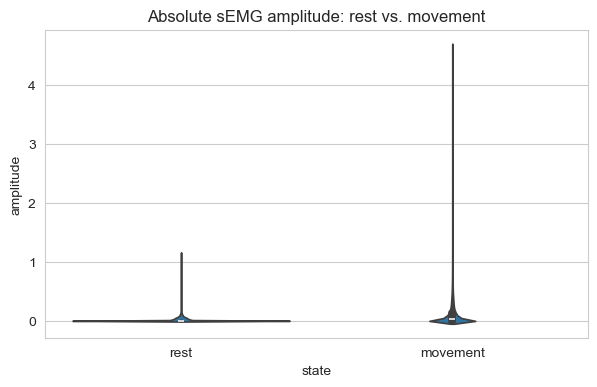

In [5]:
rest_mask = restimulus == 0
move_mask = restimulus > 0

abs_emg = np.abs(emg)
rest_values = abs_emg[rest_mask].ravel()
move_values = abs_emg[move_mask].ravel()

df_amp = pd.DataFrame({
    "amplitude": np.concatenate([rest_values, move_values]),
    "state": ["rest"] * len(rest_values) + ["movement"] * len(move_values),
})

plt.figure(figsize=(7, 4))
# sample_size = min(len(df_amp), 50000)
sns.violinplot(data=df_amp, x="state", y="amplitude")
plt.title("Absolute sEMG amplitude: rest vs. movement")
plt.show()


### Movement-to-movement differences
Compare per-channel mean absolute value (MAV) for a few movements.


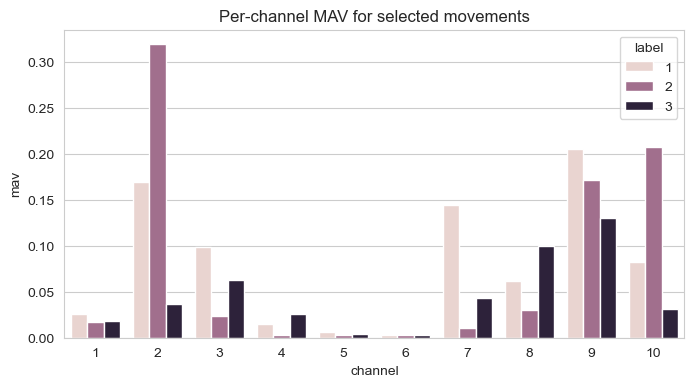

In [6]:
movement_labels = [1, 2, 3]  # choose a few gesture IDs
rows = []
for label in movement_labels:
    mask = restimulus == label
    if not np.any(mask):
        continue
    mav = np.mean(np.abs(emg[mask]), axis=0)
    for ch, value in enumerate(mav, start=1):
        rows.append({"label": label, "channel": ch, "mav": value})

df_mav = pd.DataFrame(rows)
plt.figure(figsize=(8, 4))
sns.barplot(data=df_mav, x="channel", y="mav", hue="label")
plt.title("Per-channel MAV for selected movements")
plt.show()


### Channel correlations
Inspect correlation structure across channels during movement.


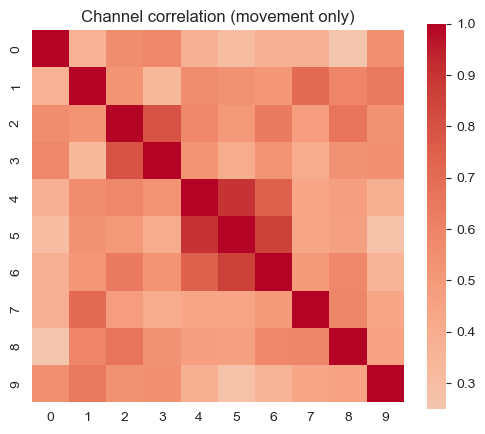

In [7]:
move_emg = emg[move_mask]
corr = np.corrcoef(move_emg, rowvar=False)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Channel correlation (movement only)")
plt.show()


### Repetition effects (fatigue hint)
Track average absolute amplitude across repetitions for one movement.


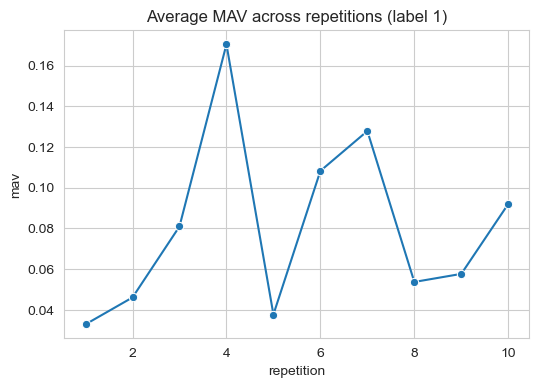

In [8]:
target_label = 1
rows = []
for rep in sorted(np.unique(rerepetition)):
    mask = (restimulus == target_label) & (rerepetition == rep)
    if not np.any(mask):
        continue
    mav = np.mean(np.abs(emg[mask]))
    rows.append({"repetition": rep, "mav": mav})

df_rep = pd.DataFrame(rows)
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_rep, x="repetition", y="mav", marker="o")
plt.title(f"Average MAV across repetitions (label {target_label})")
plt.show()


## Overall dataset analysis


### Database overview


In [9]:
import pickle
import numpy as np
import pandas as pd

from IPython.display import display

# --- High-level database summary ---
subject_ids = sorted(db.keys())
n_subjects = len(subject_ids)

print("=== Database summary ===")
print(f"Number of subjects      : {n_subjects}")
print(f"Subject IDs             : {subject_ids}")

# Collect exercises per subject
exercises_per_subject = {
    sid: sorted(db[sid]["exercises"].keys())
    for sid in subject_ids
}
unique_ex_counts = sorted({len(ex_ids) for ex_ids in exercises_per_subject.values()})
print(f"Exercises per subject   : {unique_ex_counts} (unique counts)\n")


# --- Example: show array shapes for one reference recording ---
ref_subj = subject_ids[0]
ref_ex = exercises_per_subject[ref_subj][0]
ref_rec = db[ref_subj]["exercises"][ref_ex]

emg = ref_rec["emg"]
glove = ref_rec["glove"]
stimulus = ref_rec["stimulus"]
restimulus_raw = ref_rec["restimulus"]
rerepetition = ref_rec["rerepetition"]

movement_maps = _build_movement_id_maps(db[ref_subj]["exercises"])
restimulus = _remap_restimulus(restimulus_raw, movement_maps[ref_ex])

# --- Movement IDs per exercise (remapped) ---
print(f"\nUnique remapped movement IDs for Subject {ref_subj} per exercise:")
for ex_id in exercises_per_subject[ref_subj]:
    rest_ids = np.unique(
        _remap_restimulus(
            db[ref_subj]["exercises"][ex_id]["restimulus"],
            movement_maps[ex_id],
        )
    )
    print(f"  Exercise {ex_id}: {sorted(rest_ids.tolist())}")


=== Database summary ===
Number of subjects      : 27
Subject IDs             : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Exercises per subject   : [3] (unique counts)


Unique remapped movement IDs for Subject 1 per exercise:
  Exercise 1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Exercise 2: [0, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
  Exercise 3: [0, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]


### Subject-level amplitude variability


In [10]:
def movement_amplitudes_for_exercise(rec: dict, movement_lookup: np.ndarray):
    """
    Compute mean absolute amplitudes (MAV) per movement label (>0) for EMG and glove,
    using globally remapped movement IDs (same mapping as modeling).
    """
    emg = rec["emg"]                # [T, n_emg]
    glove = rec["glove"]            # [T, 22]
    restimulus = _remap_restimulus(rec["restimulus"], movement_lookup)  # [T]
    
    movement_labels = sorted(lbl for lbl in np.unique(restimulus) if lbl > 0)

    emg_per_mov = {}
    glove_per_mov = {}

    for m in movement_labels:
        mask = restimulus == m
        if not np.any(mask):
            continue

        emg_seg = emg[mask, :]
        glove_seg = glove[mask, :]

        emg_amp = np.mean(np.abs(emg_seg))
        glove_amp = np.mean(np.abs(glove_seg))

        emg_per_mov[m] = emg_amp
        glove_per_mov[m] = glove_amp

    return emg_per_mov, glove_per_mov

movement_maps_ex2 = _build_movement_id_maps(db[2]["exercises"])
movement_amplitudes_for_exercise(db[2]["exercises"][1], movement_maps_ex2[1])


({np.int64(1): np.float64(0.29238064537157754),
  np.int64(2): np.float64(0.29909715555555555),
  np.int64(3): np.float64(0.18194496466431095),
  np.int64(4): np.float64(0.369595918196995),
  np.int64(5): np.float64(0.27702292013101537),
  np.int64(6): np.float64(0.27960603526907873),
  np.int64(7): np.float64(0.5774995710881652),
  np.int64(8): np.float64(0.17168431342521695),
  np.int64(9): np.float64(0.4258985884403137),
  np.int64(10): np.float64(0.19855985633144005),
  np.int64(11): np.float64(0.33019035534498076),
  np.int64(12): np.float64(0.2800123529411765)},
 {np.int64(1): np.float64(119.3850498173655),
  np.int64(2): np.float64(104.55072112731933),
  np.int64(3): np.float64(112.7829466192165),
  np.int64(4): np.float64(106.13352976996676),
  np.int64(5): np.float64(113.02700767439016),
  np.int64(6): np.float64(108.27019604686556),
  np.int64(7): np.float64(113.46749487345647),
  np.int64(8): np.float64(110.96252666518205),
  np.int64(9): np.float64(117.94371018146835),
  np

In [11]:
def subject_level_amplitudes(db: dict):
    """
    Compute subject-level average amplitudes across all movements and exercises.
    """
    rows = []

    for subject_id, subj_data in sorted(db.items()):
        all_emg_vals = []
        all_glove_vals = []
        movement_maps = _build_movement_id_maps(subj_data["exercises"])

        for ex_id, rec in sorted(subj_data["exercises"].items()):
            emg_per_mov, glove_per_mov = movement_amplitudes_for_exercise(
                rec,
                movement_maps[ex_id],
            )

            all_emg_vals.extend(emg_per_mov.values())
            all_glove_vals.extend(glove_per_mov.values())

        if not all_emg_vals or not all_glove_vals:
            continue

        all_emg_vals = np.asarray(all_emg_vals)
        all_glove_vals = np.asarray(all_glove_vals)

        rows.append({
            "subject_id": subject_id,
            "emg_mean": all_emg_vals.mean(),
            "emg_std": all_emg_vals.std(),
            "glove_mean": all_glove_vals.mean(),
            "glove_std": all_glove_vals.std(),
            "n_movements": len(all_emg_vals),
        })

    return pd.DataFrame(rows).set_index("subject_id").sort_index()


summary_df = subject_level_amplitudes(db)
print("Subject-level amplitude summary:")
summary_df


Subject-level amplitude summary:


,emg_mean,emg_std,glove_mean,glove_std,n_movements
subject_id,,,,,
1,0.233630,0.107543,111.714337,8.157808,52
2,0.403482,0.155515,115.889067,10.728861,52
3,0.229384,0.141408,111.620693,10.231509,52
4,0.184305,0.085419,110.565979,8.482044,52
5,0.327741,0.176873,111.559355,9.627941,52
6,0.397927,0.191061,114.111443,8.800467,52
7,0.327197,0.162258,115.833318,10.282366,52
8,0.218437,0.105650,113.966330,8.181018,52
9,0.210378,0.125797,115.230363,9.356232,52


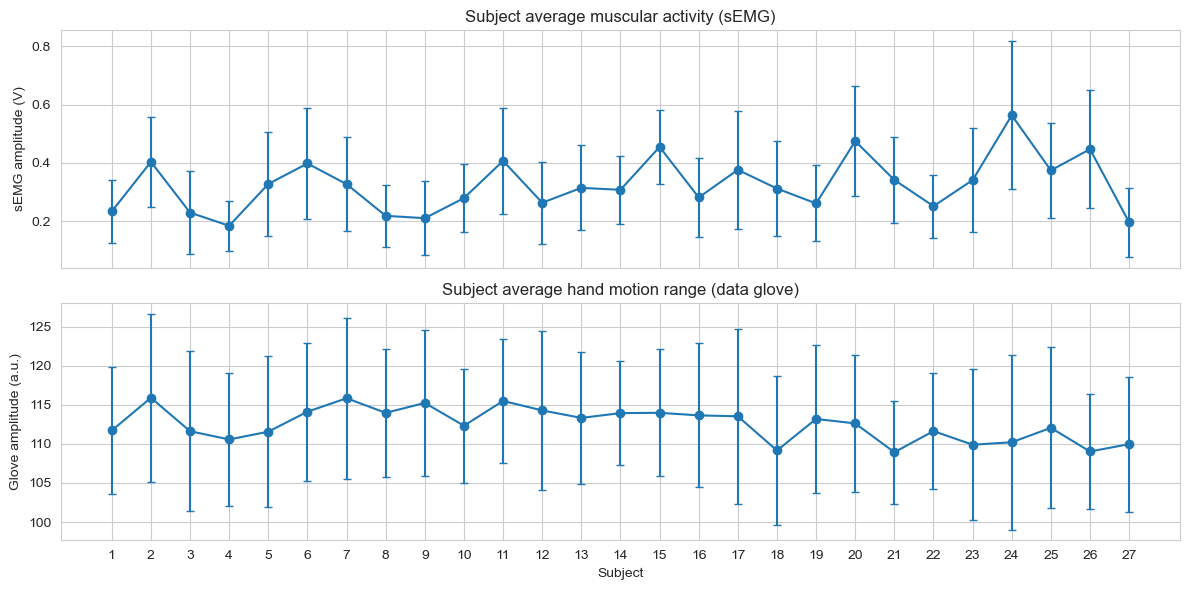

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

subject_ids = summary_df.index.values

# (a) sEMG variability
axes[0].errorbar(
    subject_ids,
    summary_df["emg_mean"],
    yerr=summary_df["emg_std"],
    fmt="-o",
    capsize=3,
)
axes[0].set_ylabel("sEMG amplitude (V)")
axes[0].set_title("Subject average muscular activity (sEMG)")

# (b) Glove variability
axes[1].errorbar(
    subject_ids,
    summary_df["glove_mean"],
    yerr=summary_df["glove_std"],
    fmt="-o",
    capsize=3,
)
axes[1].set_xlabel("Subject")
axes[1].set_ylabel("Glove amplitude (a.u.)")
axes[1].set_title("Subject average hand motion range (data glove)")

axes[1].set_xticks(subject_ids)

plt.tight_layout()
plt.show()

### Movement-level amplitude variability


In [13]:
def movement_level_variability(db: dict) -> pd.DataFrame:
    """
    Aggregate sEMG and glove mean absolute amplitudes (MAV) per *globally remapped* movement label across
    all subjects and exercises.

    Uses movement_amplitudes_for_exercise(rec, movement_lookup) with the same
    mapping as dataset construction.

    Returns:
      DataFrame indexed by movement_id with columns:
        emg_mean, emg_std, glove_mean, glove_std, n_samples
    """
    mov_emg = {}   # global_movement_id -> list of emg amplitudes
    mov_glove = {} # global_movement_id -> list of glove amplitudes

    for subject_id, subj_data in sorted(db.items()):
        movement_maps = _build_movement_id_maps(subj_data["exercises"])
        for ex_id, rec in sorted(subj_data["exercises"].items()):
            emg_per_mov, glove_per_mov = movement_amplitudes_for_exercise(
                rec,
                movement_maps[ex_id],
            )

            for m, emg_amp in emg_per_mov.items():
                glove_amp = glove_per_mov[m]

                mov_emg.setdefault(m, []).append(emg_amp)
                mov_glove.setdefault(m, []).append(glove_amp)

    rows = []
    for m in sorted(mov_emg.keys()):
        emg_vals = np.asarray(mov_emg[m])
        glove_vals = np.asarray(mov_glove[m])

        rows.append({
            "movement_id": m,
            "emg_mean": emg_vals.mean(),
            "emg_std": emg_vals.std(),
            "glove_mean": glove_vals.mean(),
            "glove_std": glove_vals.std(),
            "n_samples": len(emg_vals),
        })

    return pd.DataFrame(rows).set_index("movement_id").sort_index()


mov_df = movement_level_variability(db)
print("Movement-level amplitude variability (last 10 rows):")
mov_df.tail(10)


Movement-level amplitude variability (last 10 rows):


,emg_mean,emg_std,glove_mean,glove_std,n_samples
movement_id,,,,,
43,0.198434,0.094855,113.631615,3.627476,27
44,0.159683,0.067830,115.040903,2.747776,27
45,0.204417,0.081181,114.402590,4.206596,27
46,0.140403,0.071086,123.354109,3.620503,27
47,0.195456,0.077597,114.915867,2.843342,27
48,0.231083,0.096523,114.679524,3.482175,27
49,0.583286,0.179752,101.556010,3.442812,27
50,0.425807,0.146709,119.432376,3.615916,27
51,0.559899,0.156359,120.206490,3.357257,27


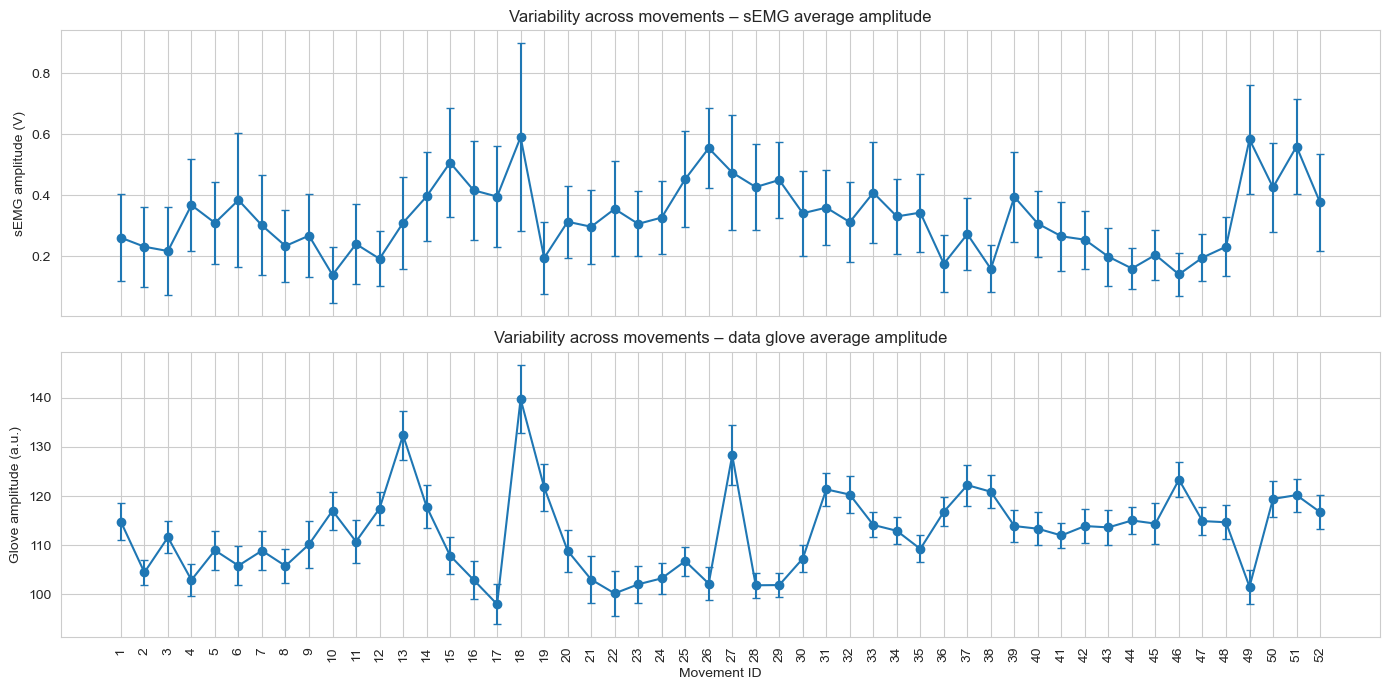

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

movement_ids = mov_df.index.values
x = np.arange(len(movement_ids))   # compact, evenly spaced integer positions

# (a) sEMG variability
axes[0].errorbar(
    x,
    mov_df["emg_mean"],
    yerr=mov_df["emg_std"],
    fmt="-o",
    capsize=3,
)
axes[0].set_ylabel("sEMG amplitude (V)")
axes[0].set_title("Variability across movements – sEMG average amplitude")

# (b) Glove variability
axes[1].errorbar(
    x,
    mov_df["glove_mean"],
    yerr=mov_df["glove_std"],
    fmt="-o",
    capsize=3,
)
axes[1].set_xlabel("Movement ID")
axes[1].set_ylabel("Glove amplitude (a.u.)")
axes[1].set_title("Variability across movements – data glove average amplitude")

axes[1].set_xticks(x)
axes[1].set_xticklabels(movement_ids, rotation=90)

plt.tight_layout()
plt.show()

### Gesture distribution analysis

Analyze gesture frequencies and class imbalance across all subjects and exercises.
We use the same global movement ID remapping as the modeling pipeline.

- Histogram of gesture frequencies across all subjects and exercises
- Identify class imbalance (e.g., dominance of rest class)


In [15]:
def compute_gesture_frequencies(db: dict) -> pd.DataFrame:
    """
    Count total samples per gesture label (restimulus) across all subjects and exercises.
    Uses globally remapped movement IDs (same mapping as modeling).
    Returns DataFrame with label, count, percentage, and label type (rest or movement).
    """
    label_counts = {}
    total_samples = 0
    
    for subject_id, subj_data in sorted(db.items()):
        exercises = subj_data["exercises"]
        movement_maps = _build_movement_id_maps(exercises)
        for ex_id, rec in sorted(exercises.items()):
            restimulus = _remap_restimulus(rec["restimulus"], movement_maps[ex_id])
            total_samples += len(restimulus)
            
            for label in np.unique(restimulus):
                count = np.sum(restimulus == label)
                label_counts[label] = label_counts.get(label, 0) + count
    
    rows = []
    for label in sorted(label_counts.keys()):
        count = label_counts[label]
        percentage = (count / total_samples) * 100
        label_type = "REST" if label == 0 else f"Movement {label}"
        rows.append({
            "label": label,
            "label_type": label_type,
            "count": count,
            "percentage": percentage,
        })
    
    return pd.DataFrame(rows)


gesture_freq_df = compute_gesture_frequencies(db)

print("=" * 80)
print("GESTURE FREQUENCY DISTRIBUTION (all subjects & exercises)")
print("=" * 80)
print(gesture_freq_df.to_string(index=False))

print(f"\nTotal samples: {gesture_freq_df['count'].sum()}")
print(f"Rest class samples: {gesture_freq_df.loc[gesture_freq_df['label'] == 0, 'count'].values[0]}")
print(f"Rest class percentage: {gesture_freq_df.loc[gesture_freq_df['label'] == 0, 'percentage'].values[0]:.2f}%")
print(f"Number of unique gestures: {len(gesture_freq_df) - 1}")


GESTURE FREQUENCY DISTRIBUTION (all subjects & exercises)
 label  label_type   count  percentage
     0        REST 7290845   58.077672
     1  Movement 1  102805    0.818928
     2  Movement 2  101570    0.809090
     3  Movement 3  113696    0.905684
     4  Movement 4   95109    0.757623
     5  Movement 5   95228    0.758571
     6  Movement 6   99451    0.792210
     7  Movement 7  100561    0.801052
     8  Movement 8  104325    0.831036
     9  Movement 9   95952    0.764338
    10 Movement 10   92413    0.736147
    11 Movement 11   88784    0.707239
    12 Movement 12   99346    0.791374
    13 Movement 13  104807    0.834875
    14 Movement 14   98023    0.780835
    15 Movement 15   95261    0.758833
    16 Movement 16   96902    0.771905
    17 Movement 17   87657    0.698261
    18 Movement 18   86181    0.686504
    19 Movement 19   96855    0.771531
    20 Movement 20   95915    0.764043
    21 Movement 21  102373    0.815486
    22 Movement 22   96809    0.771165
    23

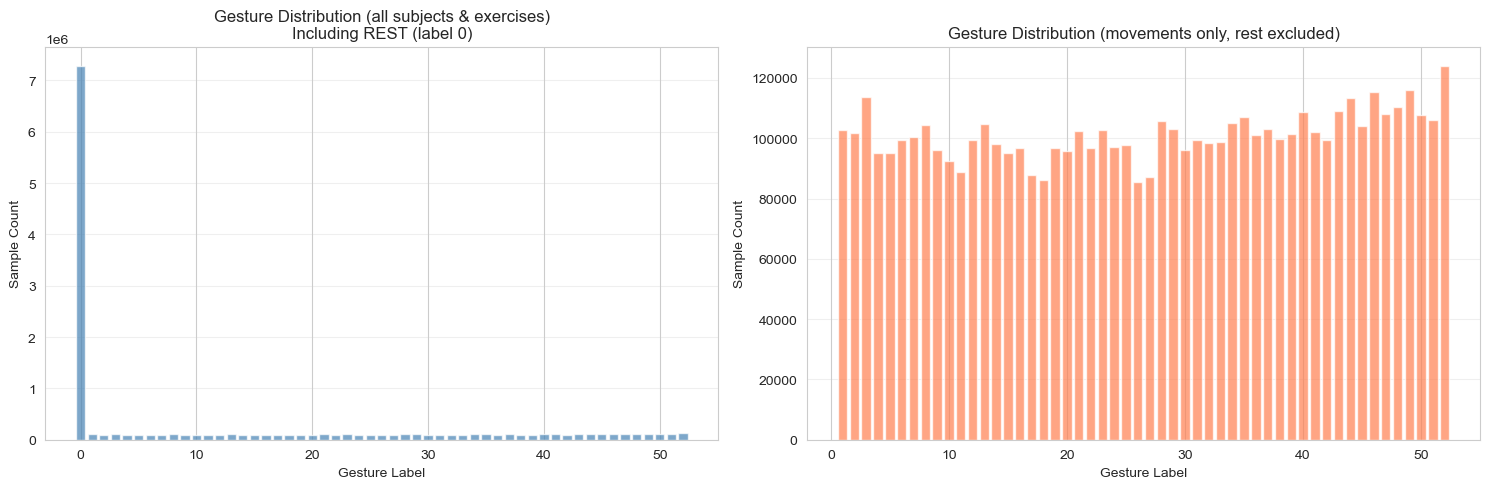

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Full histogram with all labels including rest
ax = axes[0]
ax.bar(gesture_freq_df["label"], gesture_freq_df["count"], color="steelblue", alpha=0.7)
ax.set_xlabel("Gesture Label")
ax.set_ylabel("Sample Count")
ax.set_title("Gesture Distribution (all subjects & exercises)\nIncluding REST (label 0)")
ax.grid(True, alpha=0.3, axis='y')

# (b) Excluding rest class (movements only)
gesture_freq_movements = gesture_freq_df[gesture_freq_df["label"] > 0]
ax = axes[1]
ax.bar(gesture_freq_movements["label"], gesture_freq_movements["count"], color="coral", alpha=0.7)
ax.set_xlabel("Gesture Label")
ax.set_ylabel("Sample Count")
ax.set_title("Gesture Distribution (movements only, rest excluded)")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Next step
Proceed to windowing and feature extraction.
